# Capillary Waves: Dispersion + Camera FOV / Resolution Design

This notebook combines the attached scripts into one workflow:

1. **Gravity–capillary dispersion**: diagnose the wave period, frequency, and capillary/gravity contribution ratio for wavelengths of interest.
2. **Camera geometry**: compute the angular field of view required to image a rectangular/radial region of interest (ROI) on the water surface.
3. **Pixel footprint**: estimate horizontal ground-plane resolution in mm/pixel.
4. **Vertical sea-surface height sensitivity**: estimate the vertical surface displacement that corresponds to approximately one image pixel, as a first-order geometry constraint.
5. **Parameter sweeps**: compare performance over ranges of camera height and horizontal ROI distance.

The notebook keeps internal calculations in SI units and reports final distances/resolutions in **mm**, periods in **seconds/ms**, and frequencies in **Hz**.

## 1. Imports and global settings

Only `numpy`, `pandas`, and `matplotlib` are used so the notebook is easy to run locally, on GitHub, or in Binder.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

## 2. Gravity–capillary wave dispersion

For linear surface waves with both gravity and surface tension, the dispersion relation is:

$$
\omega^2 = \left(gk + \frac{\gamma}{\rho}k^3\right)\tanh(kd)
$$

where:

- $\omega$ is angular frequency `[rad/s]`
- $k = 2\pi/\lambda$ is wavenumber `[rad/m]`
- $\lambda$ is wavelength `[m]`
- $g$ is gravitational acceleration
- $\gamma$ is surface tension
- $\rho$ is water density
- $d$ is water depth

The gravity part is $gk$ and the capillary part is $(\gamma/\rho)k^3$.
Their ratio is therefore:

$$
\frac{\text{capillary}}{\text{gravity}} =
\frac{(\gamma/\rho)k^3}{gk} = \frac{\gamma k^2}{\rho g}
$$

When this ratio is 1, gravity and capillarity contribute equally. For water with the defaults below, this occurs around **17 mm = 1.7 cm**.

Physical constants
- $g$ is gravitational acceleration = 9.8 m/s²
- $\gamma$ is surface tension =0.074 N/m
- $\rho$ is water density  = 1000.0 kg/m³
- $d$ water depth          = 100m

Deep water, in deep water tanh(kd)→1 so the bottom has no influence n the wave
$$
kd≫1 ⟺ d≫λ/2π  
$$

In [9]:
def dispersion_relation(wavelength_m, g=9.8, depth_m=100.0, gamma=0.074, rho=1000.0):
    """Return dispersion quantities for gravity-capillary surface waves."""
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    # The wavenumber k=2π/λ — how many radians of wave cycle fit in one metre. Short wavelength → large k.
    k = 2.0 * np.pi / wavelength_m
    # This computes ω2\omega^2 ω2 from the full gravity-capillary dispersion relation, gravity g*k, capillary (gamma/rho)* k**3, depth corr tanh(k*d)
    # np.tanh(k * 100) essintial 1
    omega_sq = (g * k + (gamma / rho) * k**3) * np.tanh(k * depth_m)
    omega = np.sqrt(omega_sq)
    period_s = 2.0 * np.pi / omega
    frequency_hz = 1.0 / period_s
    capillary_to_gravity = (gamma / rho) * k**2 / g
    return {
        "wavelength_m": wavelength_m,
        "k_rad_per_m": k,
        "omega_rad_per_s": omega,
        "period_s": period_s,
        "frequency_hz": frequency_hz,
        "capillary_to_gravity": capillary_to_gravity,
    }

# Creates 100 wavelength values from 1 mm to 100 mm
wavelength_m = np.arange(0.001, 0.101, 0.001)
disp = dispersion_relation(wavelength_m)

# Diagnose wavelengths of special interest.
wl_markers_m = np.array([0.017, 0.008])
marker_disp = dispersion_relation(wl_markers_m)

df_markers = pd.DataFrame({
    "WL [mm]": wl_markers_m * 1e3,
    "T [ms]": marker_disp["period_s"] * 1e3,
    "f [Hz]": marker_disp["frequency_hz"],
    "C/G ratio [-]": marker_disp["capillary_to_gravity"],
})
df_markers

,WL [mm],T [ms],f [Hz],C/G ratio [-]
0,17.0,73.247596,13.652325,1.031496
1,8.0,30.108992,33.212670,4.657849


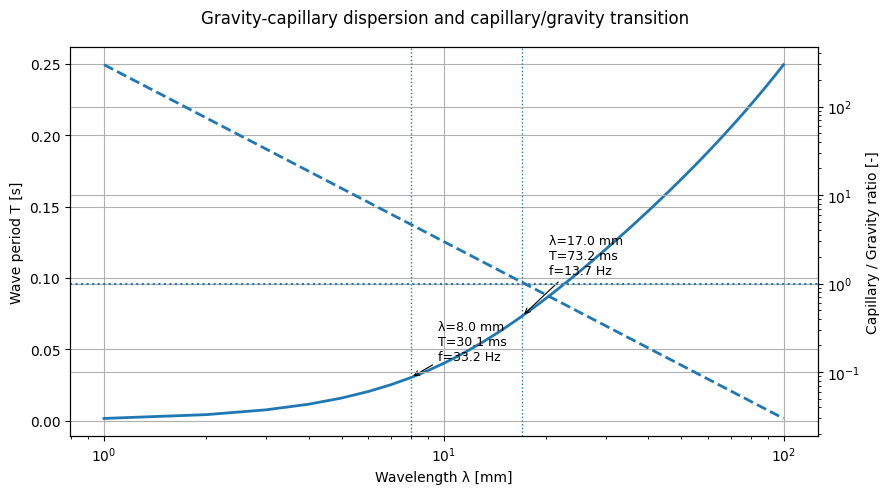

In [10]:
fig, ax1 = plt.subplots()
ax1.semilogx(wavelength_m * 1e3, disp["period_s"], linewidth=2, label="Period T [s]")
ax1.set_xlabel("Wavelength λ [mm]")
ax1.set_ylabel("Wave period T [s]")

ax2 = ax1.twinx()
ax2.loglog(wavelength_m * 1e3, disp["capillary_to_gravity"], linestyle="--", linewidth=2, label="Capillary / Gravity")
ax2.axhline(1.0, linestyle=":", linewidth=1.5, label="C/G = 1")
ax2.set_ylabel("Capillary / Gravity ratio [-]")

#loops over the two key wavelengths (wl_markers = [0.017, 0.008] m) and draws an annotated marker on the plot for each one. 
#Breaking it down line by line:
for wl in wl_markers_m:
    values = dispersion_relation(np.array([wl]))
    ax1.axvline(wl * 1e3, linestyle=":", linewidth=1)
    ax1.annotate(
        f"λ={wl*1e3:.1f} mm\nT={values['period_s'][0]*1e3:.1f} ms\nf={values['frequency_hz'][0]:.1f} Hz",
        xy=(wl * 1e3, values["period_s"][0]),
        xytext=(wl * 1e3 * 1.2, values["period_s"][0] * 1.4),
        arrowprops=dict(arrowstyle="->", lw=0.8),
        fontsize=9,
    )

fig.suptitle("Gravity-capillary dispersion and capillary/gravity transition")
fig.tight_layout()
plt.show()

### Interpretation

- At **λ ≈ 17 mm**, the capillary and gravity terms are approximately equal.
- At **λ ≈ 8 mm**, the capillary term is several times stronger than the gravity term.
- The period becomes shorter as wavelength decreases, so small capillary waves require higher frame rate.
- A practical camera frame rate should be several times higher than the wave frequency, not merely equal to it, because stereo matching and wave-shape tracking need multiple samples per cycle.

## 3. Camera FOV and pixel footprint model

The geometry assumes the camera is at height:

$$z = h_1 + h_2$$

above the water surface. The ROI starts at horizontal distance:

$$x_\text{near} = d_1 + d_2$$

and ends at:

$$x_\text{far} = x_\text{near} + W$$

The required angular field of view is the difference between the depression angles to the near and far ROI edges:

$$
\phi_\text{near}=\tan^{-1}\left(\frac{z}{x_\text{near}}\right),\quad
\phi_\text{far}=\tan^{-1}\left(\frac{z}{x_\text{far}}\right)
$$

$$
FOV = \phi_\text{near} - \phi_\text{far}
$$

For pixel footprint, each pixel center is mapped to a ray angle and projected back onto the water plane. The average spacing between neighboring projected points gives the mean horizontal resolution `[mm/pixel]`.

![Camera Geometry](camera_fov_diagram.png)

In [19]:
# h1 = 1.0   # deck height above water
# h2 = 1.0   # camera height above deck
# z=h1+h2
# Horizontal distances
# d1 = 0.0 camera offset from railing 
# d2 = 2.0 distance from ROI
# W = ROI width
# horizontal pixel count = 2048
def camera_fov_resolution(h1_m=1.0, h2_m=1.0, d1_m=0.0, d2_m=2.0, roi_width_m=0.5, nx_px=2048):
    """
    Compute FOV, mean horizontal pixel footprint, and approximate vertical height sensitivity.

    Parameters may be scalars or arrays for h2_m or d2_m.
    Returns a pandas DataFrame.
    """
    h2_arr = np.atleast_1d(np.asarray(h2_m, dtype=float))
    d2_arr = np.atleast_1d(np.asarray(d2_m, dtype=float))

    if h2_arr.size > 1 and d2_arr.size > 1:
        raise ValueError("Sweep either h2_m or d2_m, not both at the same time.")

    n = max(h2_arr.size, d2_arr.size)
    h2_arr = np.full(n, h2_arr.item()) if h2_arr.size == 1 else h2_arr
    d2_arr = np.full(n, d2_arr.item()) if d2_arr.size == 1 else d2_arr

    pixel_index = np.arange(1, nx_px + 1)
    rows = []

    for h2, d2 in zip(h2_arr, d2_arr):
        z = h1_m + h2
        x_near = d1_m + d2
        x_far = x_near + roi_width_m

        phi_far_deg = np.degrees(np.arctan(z / x_far))
        phi_near_deg = np.degrees(np.arctan(z / x_near))
        fov_deg = phi_near_deg - phi_far_deg
        fov_rad_per_pixel = np.radians(fov_deg) / nx_px

        # Ray-trace every pixel center to the water plane.
        phi_px_deg = phi_far_deg + (pixel_index - 0.5) * fov_deg / nx_px
        x_px_m = z / np.tan(np.radians(phi_px_deg))
        horizontal_res_mm_per_px = np.mean(np.abs(np.diff(x_px_m))) * 1e3

        # First-order vertical sensitivity.
        # phi = atan(z/x), so dphi/dz = x/(x^2 + z^2).
        # dz per pixel ≈ angular_pixel_size / (dphi/dz).
        x_mid = 0.5 * (x_near + x_far)
        dphi_dz = x_mid / (x_mid**2 + z**2)
        vertical_res_mm_per_px = (fov_rad_per_pixel / dphi_dz) * 1e3

        rows.append({
            "h1 deck height [m]": h1_m,
            "h2 camera above deck [m]": h2,
            "camera height z [m]": z,
            "d1 inboard offset [m]": d1_m,
            "d2 ROI near distance [m]": d2,
            "ROI width W [m]": roi_width_m,
            "x_near [m]": x_near,
            "x_far [m]": x_far,
            "phi_near [deg]": phi_near_deg,
            "phi_far [deg]": phi_far_deg,
            "FOV [deg]": fov_deg,
            "horizontal resolution [mm/px]": horizontal_res_mm_per_px,
            "vertical sensitivity approx [mm/px]": vertical_res_mm_per_px,
        })

    return pd.DataFrame(rows)

# Single baseline calculation.
baseline = camera_fov_resolution(h1_m=1.0, h2_m=1.0, d1_m=0.0, d2_m=2.0, roi_width_m=0.5, nx_px=2048)
baseline.T

,0
h1 deck height [m],1.000000
h2 camera above deck [m],1.000000
camera height z [m],2.000000
d1 inboard offset [m],0.000000
d2 ROI near distance [m],2.000000
ROI width W [m],0.500000
x_near [m],2.000000
x_far [m],2.500000
phi_near [deg],45.000000
phi_far [deg],38.659808


### Important note about vertical height sensitivity

The vertical sensitivity formula in this notebook is a **first-order geometric estimate**, not a full stereo depth/noise model.
It answers: “How much vertical water-surface motion changes the viewing angle by about one pixel?”

Real measurable height resolution also depends on:

- stereo baseline,
- lens focal length,
- camera calibration accuracy,
- texture/specular reflection quality,
- exposure and motion blur,
- stereo matching error, often subpixel or multi-pixel depending on image quality.

So this value is useful as a design constraint, but not a final measurement uncertainty.

## 4. Sweep camera height: RangeH

This reproduces the idea of `CapillaryWavesCameraFOV_RangeH_V1.py`: keep the ROI fixed and sweep camera height.

In [20]:
h2_sweep = np.arange(0.0, 3.01, 0.01)
range_h = camera_fov_resolution(
    h1_m=1.0,
    h2_m=h2_sweep,
    d1_m=0.0,
    d2_m=2.0,
    roi_width_m=0.5,
    nx_px=2048,
)
range_h.head()

,h1 deck height [m],h2 camera above deck [m],camera height z [m],d1 inboard offset [m],d2 ROI near distance [m],ROI width W [m],x_near [m],x_far [m],phi_near [deg],phi_far [deg],FOV [deg],horizontal resolution [mm/px],vertical sensitivity approx [mm/px]
0,1.0,0.00,1.00,0.0,2.0,0.5,2.0,2.5,26.565051,21.801409,4.763642,0.244138,0.109384
1,1.0,0.01,1.01,0.0,2.0,0.5,2.0,2.5,26.793776,21.998708,4.795067,0.244138,0.110471
2,1.0,0.02,1.02,0.0,2.0,0.5,2.0,2.5,27.021582,22.195460,4.826122,0.244138,0.111558
3,1.0,0.03,1.03,0.0,2.0,0.5,2.0,2.5,27.248467,22.391661,4.856806,0.244138,0.112644
4,1.0,0.04,1.04,0.0,2.0,0.5,2.0,2.5,27.474432,22.587311,4.887121,0.244138,0.113730


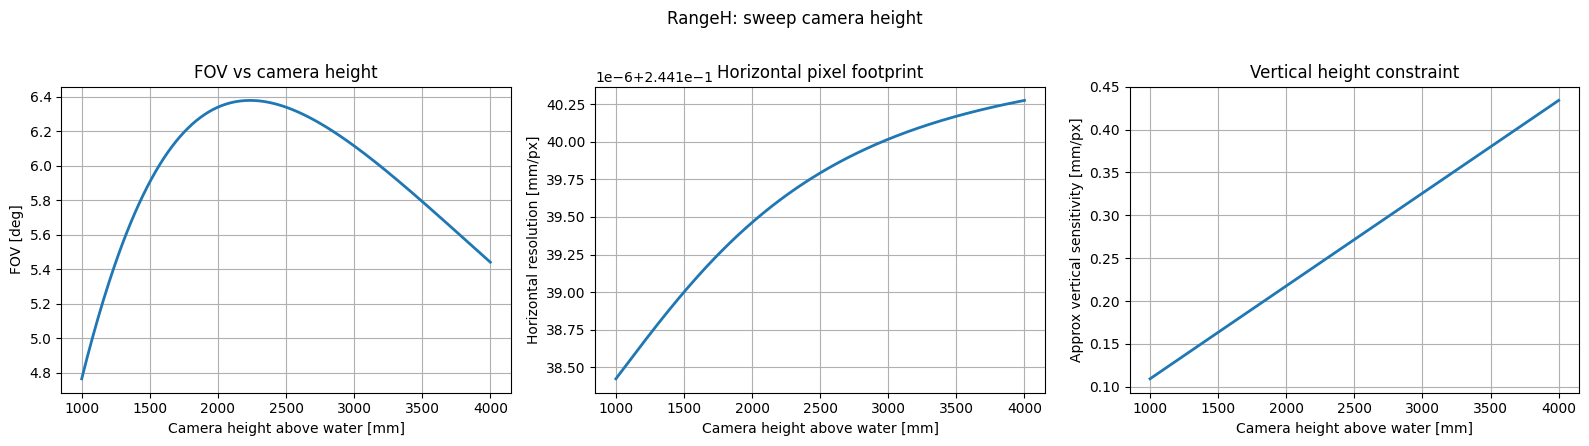

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x = range_h["camera height z [m]"] * 1e3

axes[0].plot(x, range_h["FOV [deg]"], linewidth=2)
axes[0].set_xlabel("Camera height above water [mm]")
axes[0].set_ylabel("FOV [deg]")
axes[0].set_title("FOV vs camera height")

axes[1].plot(x, range_h["horizontal resolution [mm/px]"], linewidth=2)
axes[1].set_xlabel("Camera height above water [mm]")
axes[1].set_ylabel("Horizontal resolution [mm/px]")
axes[1].set_title("Horizontal pixel footprint")

axes[2].plot(x, range_h["vertical sensitivity approx [mm/px]"], linewidth=2)
axes[2].set_xlabel("Camera height above water [mm]")
axes[2].set_ylabel("Approx vertical sensitivity [mm/px]")
axes[2].set_title("Vertical height constraint")

fig.suptitle("RangeH: sweep camera height")
fig.tight_layout()
plt.show()

## 5. Sweep ROI distance: RangeD

This reproduces the idea of `CapillaryWavesCameraFOV_RangeD_V1.py`: keep the camera height fixed and sweep the horizontal distance from the camera/ship to the ROI.

In [ ]:
d2_sweep = np.arange(1.0, 4.01, 0.01)
range_d = camera_fov_resolution(
    h1_m=1.0,
    h2_m=1.0,
    d1_m=0.0,
    d2_m=d2_sweep,
    roi_width_m=0.5,
    nx_px=2048,
)
range_d.head()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x = range_d["d2 ROI near distance [m]"] * 1e3

axes[0].plot(x, range_d["FOV [deg]"], linewidth=2)
axes[0].set_xlabel("ROI near distance d2 [mm]")
axes[0].set_ylabel("FOV [deg]")
axes[0].set_title("FOV vs ROI distance")

axes[1].plot(x, range_d["horizontal resolution [mm/px]"], linewidth=2)
axes[1].set_xlabel("ROI near distance d2 [mm]")
axes[1].set_ylabel("Horizontal resolution [mm/px]")
axes[1].set_title("Horizontal pixel footprint")

axes[2].plot(x, range_d["vertical sensitivity approx [mm/px]"], linewidth=2)
axes[2].set_xlabel("ROI near distance d2 [mm]")
axes[2].set_ylabel("Approx vertical sensitivity [mm/px]")
axes[2].set_title("Vertical height constraint")

fig.suptitle("RangeD: sweep ROI distance")
fig.tight_layout()
plt.show()

## 6. Design filter: find configurations that satisfy target resolution

Use this cell to screen candidate geometries. For example, for capillary waves you may want:

- horizontal footprint ≤ 0.1–0.3 mm/pixel,
- vertical geometric sensitivity ≤ target capillary wave height resolution,
- enough FOV to cover the desired ROI width.

The values below are editable.

In [ ]:

max_horizontal_mm_per_px = 0.30
max_vertical_mm_per_px = 0.30

# Example: screen the camera-height sweep
valid_h = range_h[
    (range_h["horizontal resolution [mm/px]"] <= max_horizontal_mm_per_px) &
    (range_h["vertical sensitivity approx [mm/px]"] <= max_vertical_mm_per_px)
]

print(f"Valid camera-height rows: {len(valid_h)} / {len(range_h)}")
valid_h[[
    "camera height z [m]",
    "FOV [deg]",
    "horizontal resolution [mm/px]",
    "vertical sensitivity approx [mm/px]",
]].head(10)

In [ ]:
# Example: screen the ROI-distance sweep
valid_d = range_d[
    (range_d["horizontal resolution [mm/px]"] <= max_horizontal_mm_per_px) &
    (range_d["vertical sensitivity approx [mm/px]"] <= max_vertical_mm_per_px)
]

print(f"Valid ROI-distance rows: {len(valid_d)} / {len(range_d)}")
valid_d[[
    "d2 ROI near distance [m]",
    "FOV [deg]",
    "horizontal resolution [mm/px]",
    "vertical sensitivity approx [mm/px]",
]].head(10)

## 7. Optional 2D sweep over camera height and ROI distance

The original scripts sweep one variable at a time. For design work, it is useful to sweep both `h2` and `d2` and plot a heat map of the result.

In [ ]:
h2_values = np.arange(0.0, 3.01, 0.05)
d2_values = np.arange(1.0, 4.01, 0.05)

H, D = np.meshgrid(h2_values, d2_values, indexing="ij")
horizontal_map = np.zeros_like(H, dtype=float)
vertical_map = np.zeros_like(H, dtype=float)
fov_map = np.zeros_like(H, dtype=float)

for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        row = camera_fov_resolution(h1_m=1.0, h2_m=H[i, j], d1_m=0.0, d2_m=D[i, j], roi_width_m=0.5, nx_px=2048).iloc[0]
        horizontal_map[i, j] = row["horizontal resolution [mm/px]"]
        vertical_map[i, j] = row["vertical sensitivity approx [mm/px]"]
        fov_map[i, j] = row["FOV [deg]"]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    horizontal_map,
    origin="lower",
    aspect="auto",
    extent=[d2_values.min(), d2_values.max(), h2_values.min(), h2_values.max()],
)
fig.colorbar(im, ax=ax, label="Horizontal resolution [mm/px]")
ax.set_xlabel("ROI near distance d2 [m]")
ax.set_ylabel("Camera height above deck h2 [m]")
ax.set_title("2D sweep: horizontal pixel footprint")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    vertical_map,
    origin="lower",
    aspect="auto",
    extent=[d2_values.min(), d2_values.max(), h2_values.min(), h2_values.max()],
)
fig.colorbar(im, ax=ax, label="Approx vertical sensitivity [mm/px]")
ax.set_xlabel("ROI near distance d2 [m]")
ax.set_ylabel("Camera height above deck h2 [m]")
ax.set_title("2D sweep: vertical height constraint")
plt.show()

## 8. Binder / GitHub setup

To make this notebook runnable by the team:

1. Create a GitHub repository.
2. Upload this notebook and the `requirements.txt` file.
3. Go to [mybinder.org](https://mybinder.org/).
4. Paste the GitHub repository URL.
5. Set the notebook path to `Capillary_Waves_Camera_FOV_and_Dispersion.ipynb`.
6. Binder will generate a launch link that everyone can use in the browser.

Recommended repository structure:

```text
capillary-wave-camera-design/
├── Capillary_Waves_Camera_FOV_and_Dispersion.ipynb
├── requirements.txt
└── README.md
```